# Test Notebook: Stage 3 EDA via Project Scripts

This notebook imports and uses the production EDA scripts defined in `src/flight_fare/stage3_eda.py`, aligned to **Step 3: Exploratory Data Analysis (EDA)** in `project.md`.

## Project Step 3 Coverage
- Descriptive statistics by airline, source, destination, and season
- Correlation analysis for numeric features
- Visual analysis (distributions, boxplot, monthly trend, heatmap)
- KPI exploration (average fare per airline, route frequency, seasonal variation, top expensive routes)

In [12]:
from __future__ import annotations

import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt


import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebook' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from flight_fare.settings import Stage3Settings
from flight_fare.stage3_eda import (
    build_correlation_heatmap_figure,
    build_distribution_figure,
    build_monthly_fare_figure,
    build_route_boxplot_figure,
    compute_correlation_matrix,
    compute_descriptive_stats,
    compute_kpi_tables,
    prepare_eda_dataframe,
    run_stage_3,
)
from flight_fare.preprocessing import TARGET_COLUMN
from flight_fare.settings import Stage4Settings, Stage5Settings
from flight_fare.stage4_baseline import run_stage_4
from flight_fare.stage5_advanced import run_stage_5

BASE_FARE_COLUMN = 'Base Fare (BDT)'
TAX_COLUMN = 'Tax & Surcharge (BDT)'


In [13]:
# Load dataset configured for Stage 3 and prepare helper EDA columns.
settings = Stage3Settings.from_env()
raw_df = pd.read_csv(settings.dataset_path)
eda_df = prepare_eda_dataframe(raw_df)

print(f'Input path: {settings.dataset_path}')
print(f'Rows: {len(eda_df):,} | Columns: {len(eda_df.columns)}')
eda_df.head()

Input path: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_2\cleaned_dataset.csv
Rows: 57,000 | Columns: 21


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,...,Booking Source,Total Fare (BDT),Seasonality,Days Before Departure,Departure Month,Departure Day,Departure Weekday,Departure Season,Route,Booking Window
0,Malaysian Airlines,CXB,Cox'S Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,...,Online Website,26300.908775,Regular,10,11,17,0,post_monsoon,CXB -> CCU,mid_term_8_14
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,...,Travel Agency,11805.395471,Regular,14,3,16,6,pre_monsoon,BZL -> CGP,mid_term_8_14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,...,Travel Agency,51864.874251,Winter Holidays,83,12,13,5,winter,ZYL -> KUL,very_early_61_plus
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,...,Direct Booking,4635.607340,Regular,56,5,30,4,pre_monsoon,RJH -> DAC,early_31_60
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,...,Direct Booking,74130.377068,Regular,90,4,25,4,pre_monsoon,SPD -> YYZ,very_early_61_plus


In [14]:
# Step 3.1 and 3.3: descriptive statistics, correlation, and KPIs.
descriptive_stats = compute_descriptive_stats(eda_df)
correlation_matrix = compute_correlation_matrix(eda_df)
kpi_tables = compute_kpi_tables(eda_df, top_n_routes=settings.top_n_routes)

avg_key = 'average_fare_per_route' if 'average_fare_per_route' in kpi_tables else 'average_fare_per_airline'
print(f'Average fare ({avg_key}) (top 10):')
display(kpi_tables[avg_key].head(10))

print('Most popular routes (top 10):')
display(kpi_tables['route_frequency'].head(10))

print('Seasonal fare variation:')
display(kpi_tables['seasonal_fare'])

print('Top expensive routes:')
display(kpi_tables['top_expensive_routes'].head(5))

print('Correlation matrix shape:', correlation_matrix.shape)


Average fare (average_fare_per_route) (top 10):


,Route,flight_count,avg_total_fare_bdt,median_total_fare_bdt,min_total_fare_bdt,max_total_fare_bdt,std_total_fare_bdt
114,SPD -> BKK,388,117951.572347,90550.184333,11250.917819,382094.210298,86243.018998
55,CXB -> YYZ,383,117848.709744,89982.330295,11444.006137,375503.416420,87253.415019
51,CXB -> LHR,372,116667.654377,88115.764364,11535.367574,403830.579811,88880.174711
48,CXB -> JFK,389,116476.311601,80911.793763,12938.316290,390007.677879,87632.106459
10,BZL -> JFK,371,115968.436285,83507.543739,11727.698289,482855.598026,88916.368615
146,ZYL -> KUL,395,115656.924042,88107.691798,12105.730559,409699.741173,87215.080003
103,RJH -> DXB,373,115485.474481,87237.960386,8826.598394,415329.830749,87678.724182
122,SPD -> DXB,385,115426.280535,83027.010753,10254.299303,417567.164294,90217.329613
13,BZL -> LHR,376,114788.651011,77794.005945,10860.274709,420999.975817,87697.744290
106,RJH -> JFK,404,114415.728521,82390.508637,13352.394669,522606.373836,88764.110551


Most popular routes (top 10):


,Route,flight_count
110,RJH -> SIN,417
64,DAC -> DXB,413
17,BZL -> YYZ,410
19,CGP -> BKK,408
43,CXB -> DEL,408
9,BZL -> JED,407
106,RJH -> JFK,404
22,CGP -> CXB,404
120,SPD -> DEL,404
33,CGP -> RJH,403


Seasonal fare variation:


,Departure Season,flight_count,avg_total_fare_bdt,median_total_fare_bdt
3,winter,13859,78771.520102,46528.810416
0,monsoon,19000,69222.602410,40269.280954
2,pre_monsoon,14416,68604.202442,40434.859555
1,post_monsoon,9725,67126.570491,39073.043948


Top expensive routes:


,Route,flight_count,avg_total_fare_bdt,median_total_fare_bdt,max_total_fare_bdt
114,SPD -> BKK,388,117951.572347,90550.184333,382094.210298
55,CXB -> YYZ,383,117848.709744,89982.330295,375503.416420
51,CXB -> LHR,372,116667.654377,88115.764364,403830.579811
48,CXB -> JFK,389,116476.311601,80911.793763,390007.677879
10,BZL -> JFK,371,115968.436285,83507.543739,482855.598026


Correlation matrix shape: (6, 6)


In [15]:
# Step 3.2: render EDA visuals inline from script plotting builders (no image files saved).
import matplotlib.pyplot as plt

eda_figures = {
    'total_fare_distribution': build_distribution_figure(
        eda_df, TARGET_COLUMN, 'Total Fare Distribution'
    ),
    'route_boxplot': build_route_boxplot_figure(
        eda_df, max_routes=settings.max_airlines_boxplot
    ),
    'monthly_average_fare': build_monthly_fare_figure(eda_df),
    'correlation_heatmap': build_correlation_heatmap_figure(correlation_matrix),
}

optional_distribution_columns = [
    (BASE_FARE_COLUMN, 'base_fare_distribution', 'Base Fare Distribution'),
    (TAX_COLUMN, 'tax_distribution', 'Tax and Surcharge Distribution'),
]

for column_name, figure_key, title in optional_distribution_columns:
    if column_name in eda_df.columns:
        eda_figures[figure_key] = build_distribution_figure(eda_df, column_name, title)
    else:
        print(f'Skipping {figure_key}: column not found -> {column_name}')

for plot_name, fig in eda_figures.items():
    print(plot_name)
    display(fig)
    plt.close(fig)

list(eda_figures.keys())


Skipping base_fare_distribution: column not found -> Base Fare (BDT)
Skipping tax_distribution: column not found -> Tax & Surcharge (BDT)
total_fare_distribution


<Figure size 1000x600 with 1 Axes>

route_boxplot


<Figure size 1200x700 with 1 Axes>

monthly_average_fare


<Figure size 1000x600 with 1 Axes>

correlation_heatmap


<Figure size 1000x800 with 2 Axes>

['total_fare_distribution',
 'route_boxplot',
 'monthly_average_fare',
 'correlation_heatmap']

In [16]:
# Step 3.2 plots are rendered inline in the previous cell (no file-based preview needed).
print('Inline Stage 3 plots rendered above.')


Inline Stage 3 plots rendered above.


In [17]:
# Full Stage 3 pipeline end-to-end and inspect summary artifact.
outputs = run_stage_3(settings=settings)
summary = json.loads(Path(outputs.summary_report_path).read_text(encoding='utf-8'))

print('Summary report:', outputs.summary_report_path)
print('Artifacts directory:', outputs.plots_directory.parent)
summary['kpis']

2026-03-01 10:53:31 | INFO | flight_fare.stage3 | run_stage_3 | Starting Stage 3 pipeline execution.
2026-03-01 10:53:31 | INFO | flight_fare.stage3 | run_stage_3 | Input dataset path: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_2\cleaned_dataset.csv
2026-03-01 10:53:31 | INFO | flight_fare.stage3 | load_flight_dataset | Loading dataset from C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_2\cleaned_dataset.csv (attempt 1/3).
2026-03-01 10:53:32 | INFO | flight_fare.stage3 | load_flight_dataset | Dataset loaded successfully with 57000 rows.
2026-03-01 10:53:36 | INFO | flight_fare.stage3 | run_stage_3 | Stage 3 completed successfully.
2026-03-01 10:53:36 | INFO | flight_fare.stage3 | run_stage_3 | Summary report: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_3\stage3_summary_report.json
2026-03-01 10:53:36 | INFO | flight_fare.stage3 | run_stage_3 | Plots directory: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\

Summary report: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_3\stage3_summary_report.json
Artifacts directory: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_3


{'most_popular_route': {'route': 'RJH -> SIN', 'flight_count': 417},
 'top_5_most_expensive_routes': [{'Route': 'SPD -> BKK',
   'flight_count': 388,
   'avg_total_fare_bdt': 117951.57234699473,
   'median_total_fare_bdt': 90550.18433284774,
   'max_total_fare_bdt': 382094.21029785706},
  {'Route': 'CXB -> YYZ',
   'flight_count': 383,
   'avg_total_fare_bdt': 117848.70974427456,
   'median_total_fare_bdt': 89982.33029537628,
   'max_total_fare_bdt': 375503.4164202505},
  {'Route': 'CXB -> LHR',
   'flight_count': 372,
   'avg_total_fare_bdt': 116667.65437664649,
   'median_total_fare_bdt': 88115.76436445225,
   'max_total_fare_bdt': 403830.5798113806},
  {'Route': 'CXB -> JFK',
   'flight_count': 389,
   'avg_total_fare_bdt': 116476.31160148268,
   'median_total_fare_bdt': 80911.79376298173,
   'max_total_fare_bdt': 390007.6778787857},
  {'Route': 'BZL -> JFK',
   'flight_count': 371,
   'avg_total_fare_bdt': 115968.43628519747,
   'median_total_fare_bdt': 83507.54373913968,
   'max_t

2026-03-01 10:53:36 | INFO | flight_fare.stage4 | run_stage_4 | Starting Stage 4 baseline model pipeline.
2026-03-01 10:53:38 | INFO | flight_fare.stage4 | run_stage_4 | Stage 4 completed successfully.
2026-03-01 10:53:38 | INFO | flight_fare.stage4 | run_stage_4 | Test metrics: R2=0.5700 MAE=40677.8359 RMSE=53537.9059


Stage 4 summary: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_4\stage4_summary_report.json
Stage 4 metrics: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_4\baseline_metrics.json
Stage 4 test metrics:


,r2,mae,rmse
baseline_linear_regression,0.570033,40677.835931,53537.905867


Stage 4 diagnostic plots (from stage4_baseline.py):
actual_vs_predicted.png


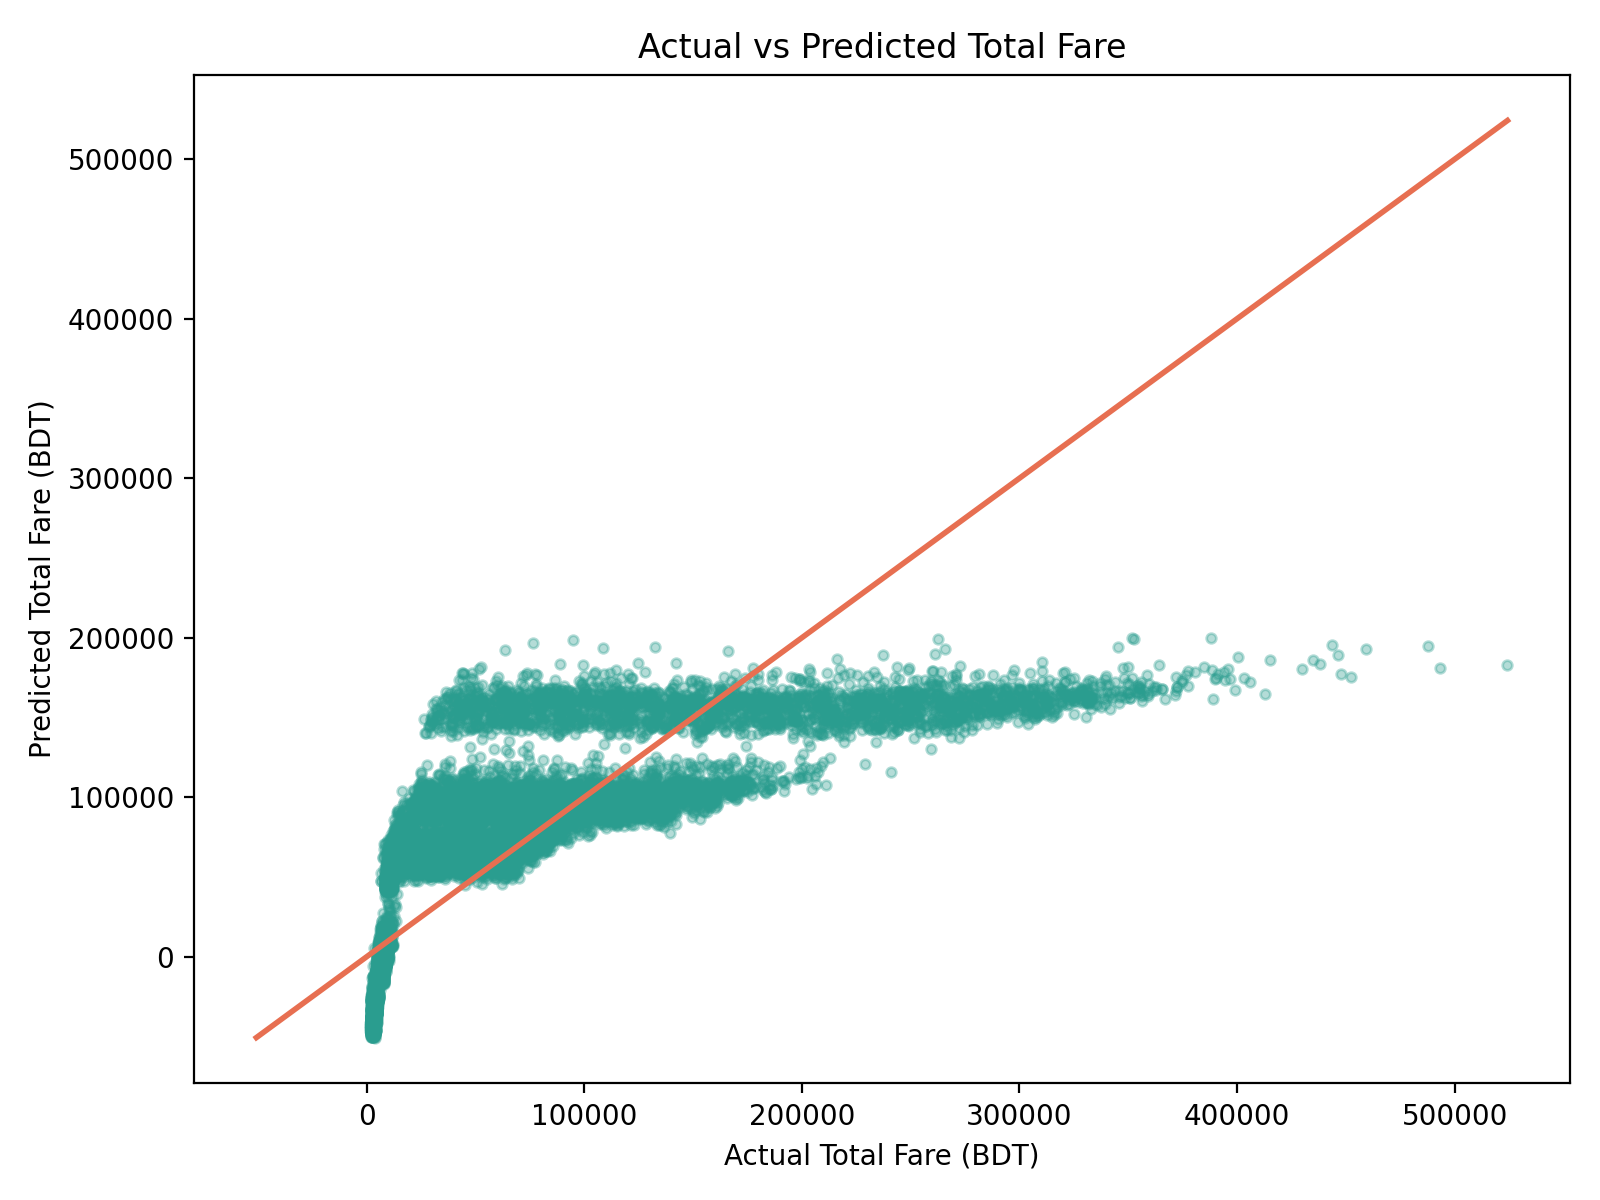

residual_distribution.png


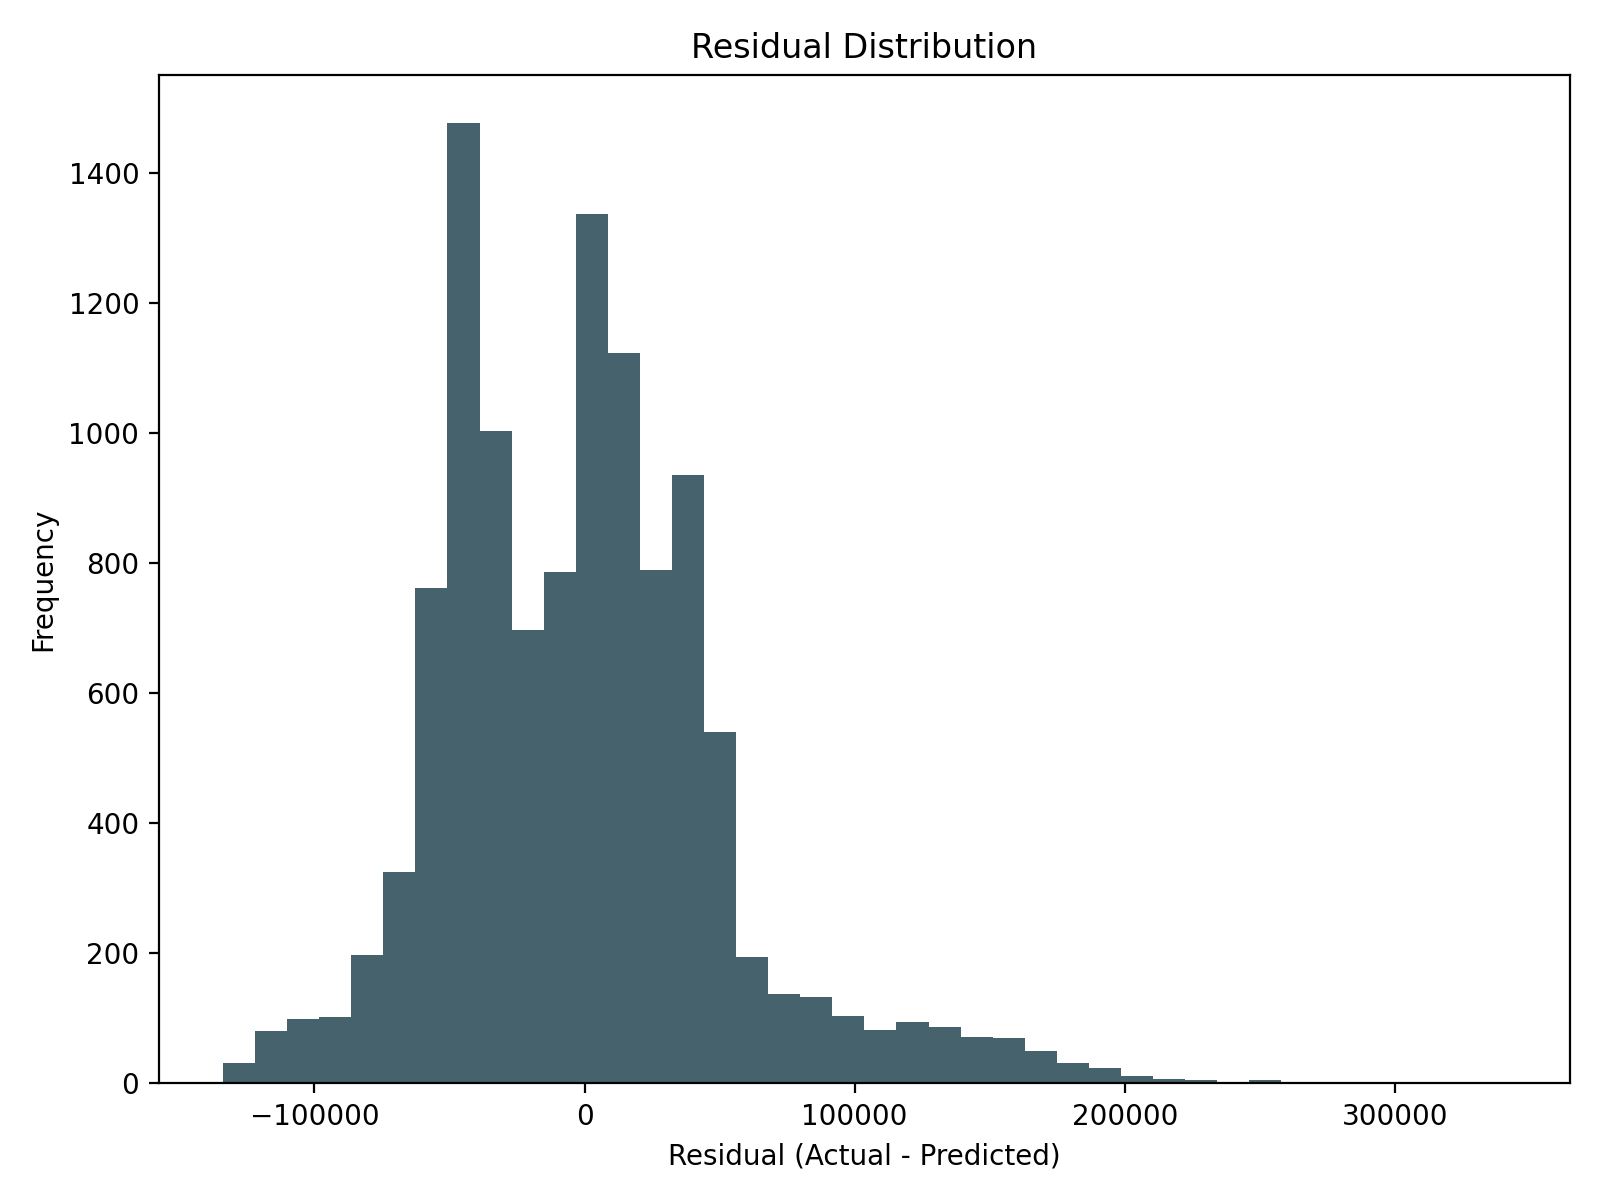

residuals_vs_predicted.png


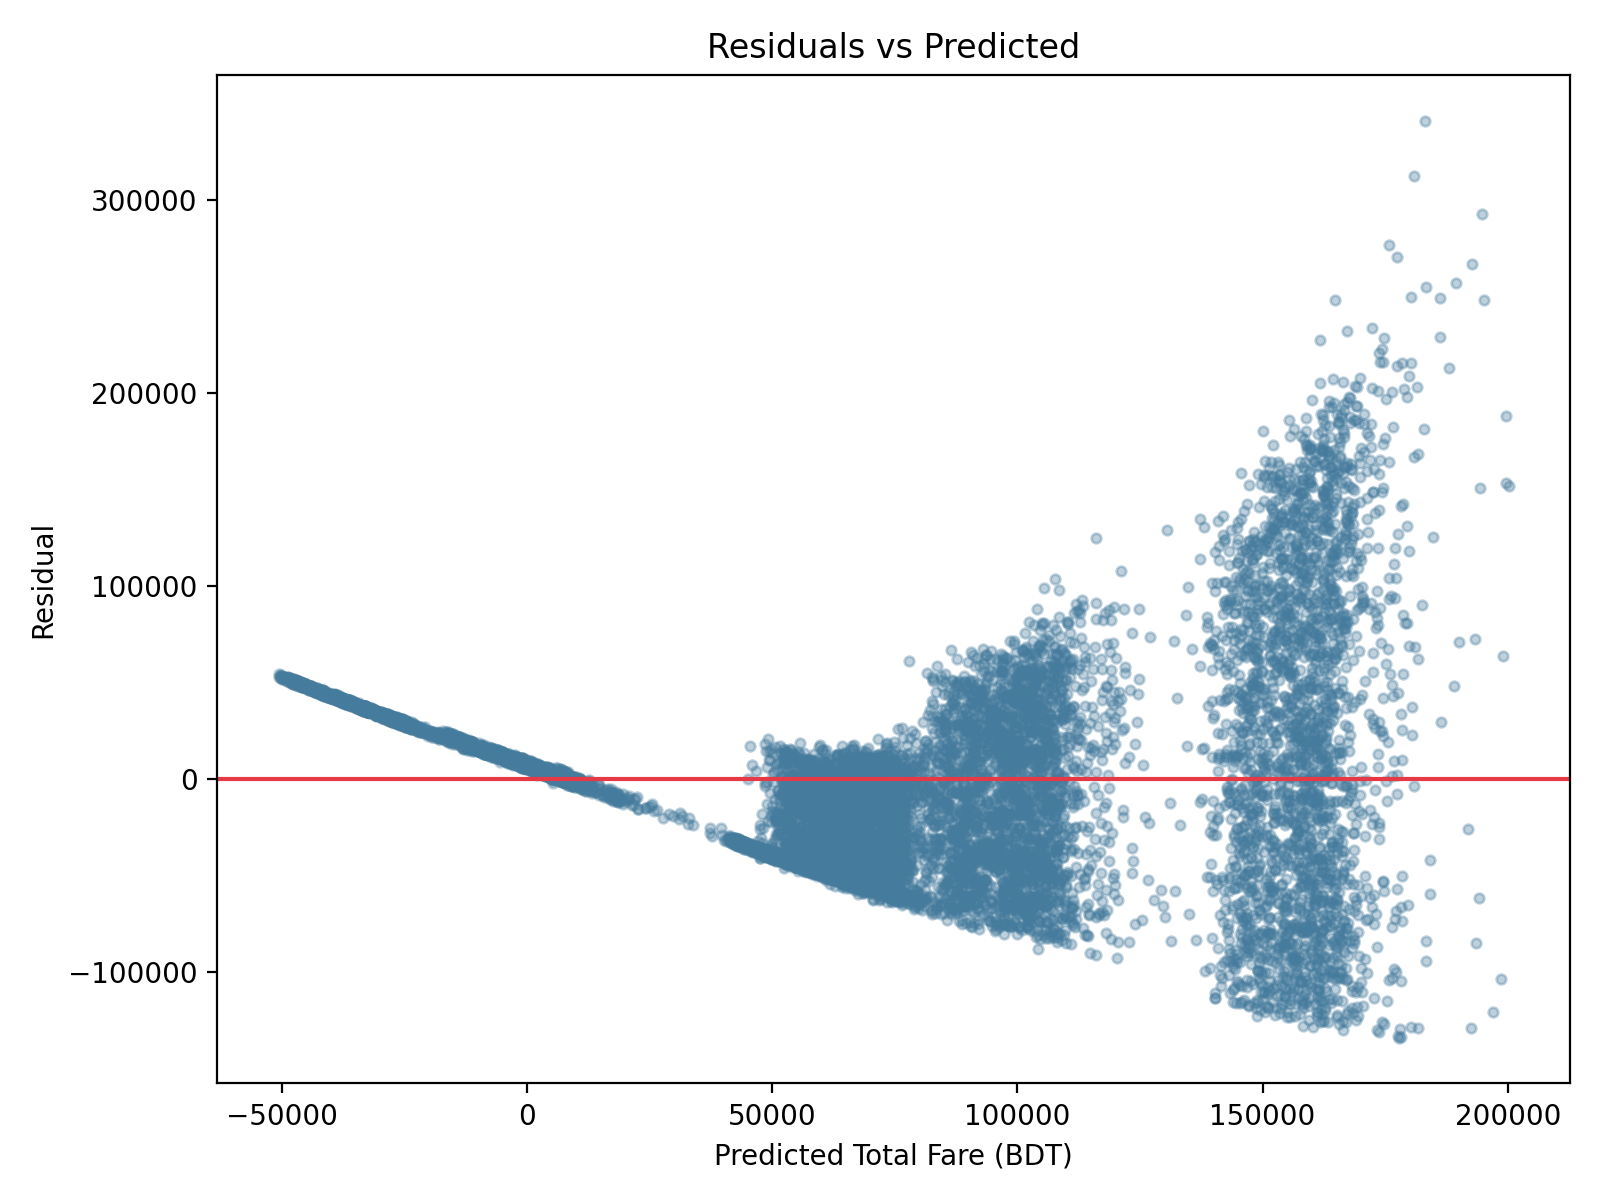

2026-03-01 10:53:38 | INFO | flight_fare.stage5 | run_stage_5 | Starting Stage 5 advanced modeling pipeline.
2026-03-01 10:53:39 | INFO | flight_fare.stage5 | run_stage_5 | Tuning sample rows: 11400 of 45600
2026-03-01 10:53:39 | INFO | flight_fare.stage5 | run_stage_5 | Tuning model: Ridge
2026-03-01 10:53:55 | INFO | flight_fare.stage5 | run_stage_5 | Completed Ridge: CV RMSE=53256.274, Test RMSE=53536.722
2026-03-01 10:53:55 | INFO | flight_fare.stage5 | run_stage_5 | Tuning model: Lasso
2026-03-01 10:58:59 | WARNING | flight_fare.stage5 | run_with_retries_and_timeout | Operation 'tune_Lasso' timed out on attempt 1/3.
2026-03-01 11:03:45 | INFO | flight_fare.stage5 | run_stage_5 | Completed Lasso: CV RMSE=53245.358, Test RMSE=53535.168
2026-03-01 11:03:45 | INFO | flight_fare.stage5 | run_stage_5 | Tuning model: DecisionTreeRegressor
2026-03-01 11:03:48 | INFO | flight_fare.stage5 | run_stage_5 | Completed DecisionTreeRegressor: CV RMSE=47027.356, Test RMSE=46952.888
2026-03-01 11:0

Stage 5 summary: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_5\stage5_summary_report.json
Stage 5 comparison table: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_5\model_comparison.csv
Stage 5 best model: C:\Users\Administrator\OneDrive\Desktop\ML-AMALITECH\artifacts\stage_5\best_model.pkl
Stage 5 model comparison (sorted by test RMSE):


,model_name,cv_rmse,train_r2,test_r2,train_mae,test_mae,train_rmse,test_rmse
0,GradientBoostingRegressor,46029.958246,0.687791,0.679272,28027.071626,28197.422941,45705.429769,46239.396283
1,RandomForestRegressor,46934.140316,0.807654,0.672679,21540.871363,28092.583301,35874.557739,46712.244792
2,DecisionTreeRegressor,47027.355958,0.676450,0.669298,28107.173364,28263.296151,46528.191057,46952.887571
3,Lasso,53245.357827,0.573899,0.570077,40557.613195,40666.708490,53395.167433,53535.168114
4,Ridge,53256.273959,0.573900,0.570052,40553.515101,40663.050985,53395.077626,53536.722088


Top 10 feature impacts from Stage 5 best model:


,feature_name,importance,importance_type,abs_importance
0,cat__Class_First Class,0.392409,feature_importance,0.392409
1,num__Duration (hrs),0.219458,feature_importance,0.219458
2,cat__Aircraft Type_Airbus A320,0.197265,feature_importance,0.197265
3,cat__Destination_CCU,0.054691,feature_importance,0.054691
4,cat__Destination Name_Netaji Subhas Chandra Bo...,0.039351,feature_importance,0.039351
5,cat__Class_Economy,0.035986,feature_importance,0.035986
6,num__Days Before Departure,0.023311,feature_importance,0.023311
7,cat__Class_Business,0.020074,feature_importance,0.020074
8,cat__Seasonality_Regular,0.012218,feature_importance,0.012218
9,cat__Seasonality_Hajj,0.003022,feature_importance,0.003022


Stage 5 diagnostic plots (from stage5_advanced.py):
bias_variance_tradeoff.png


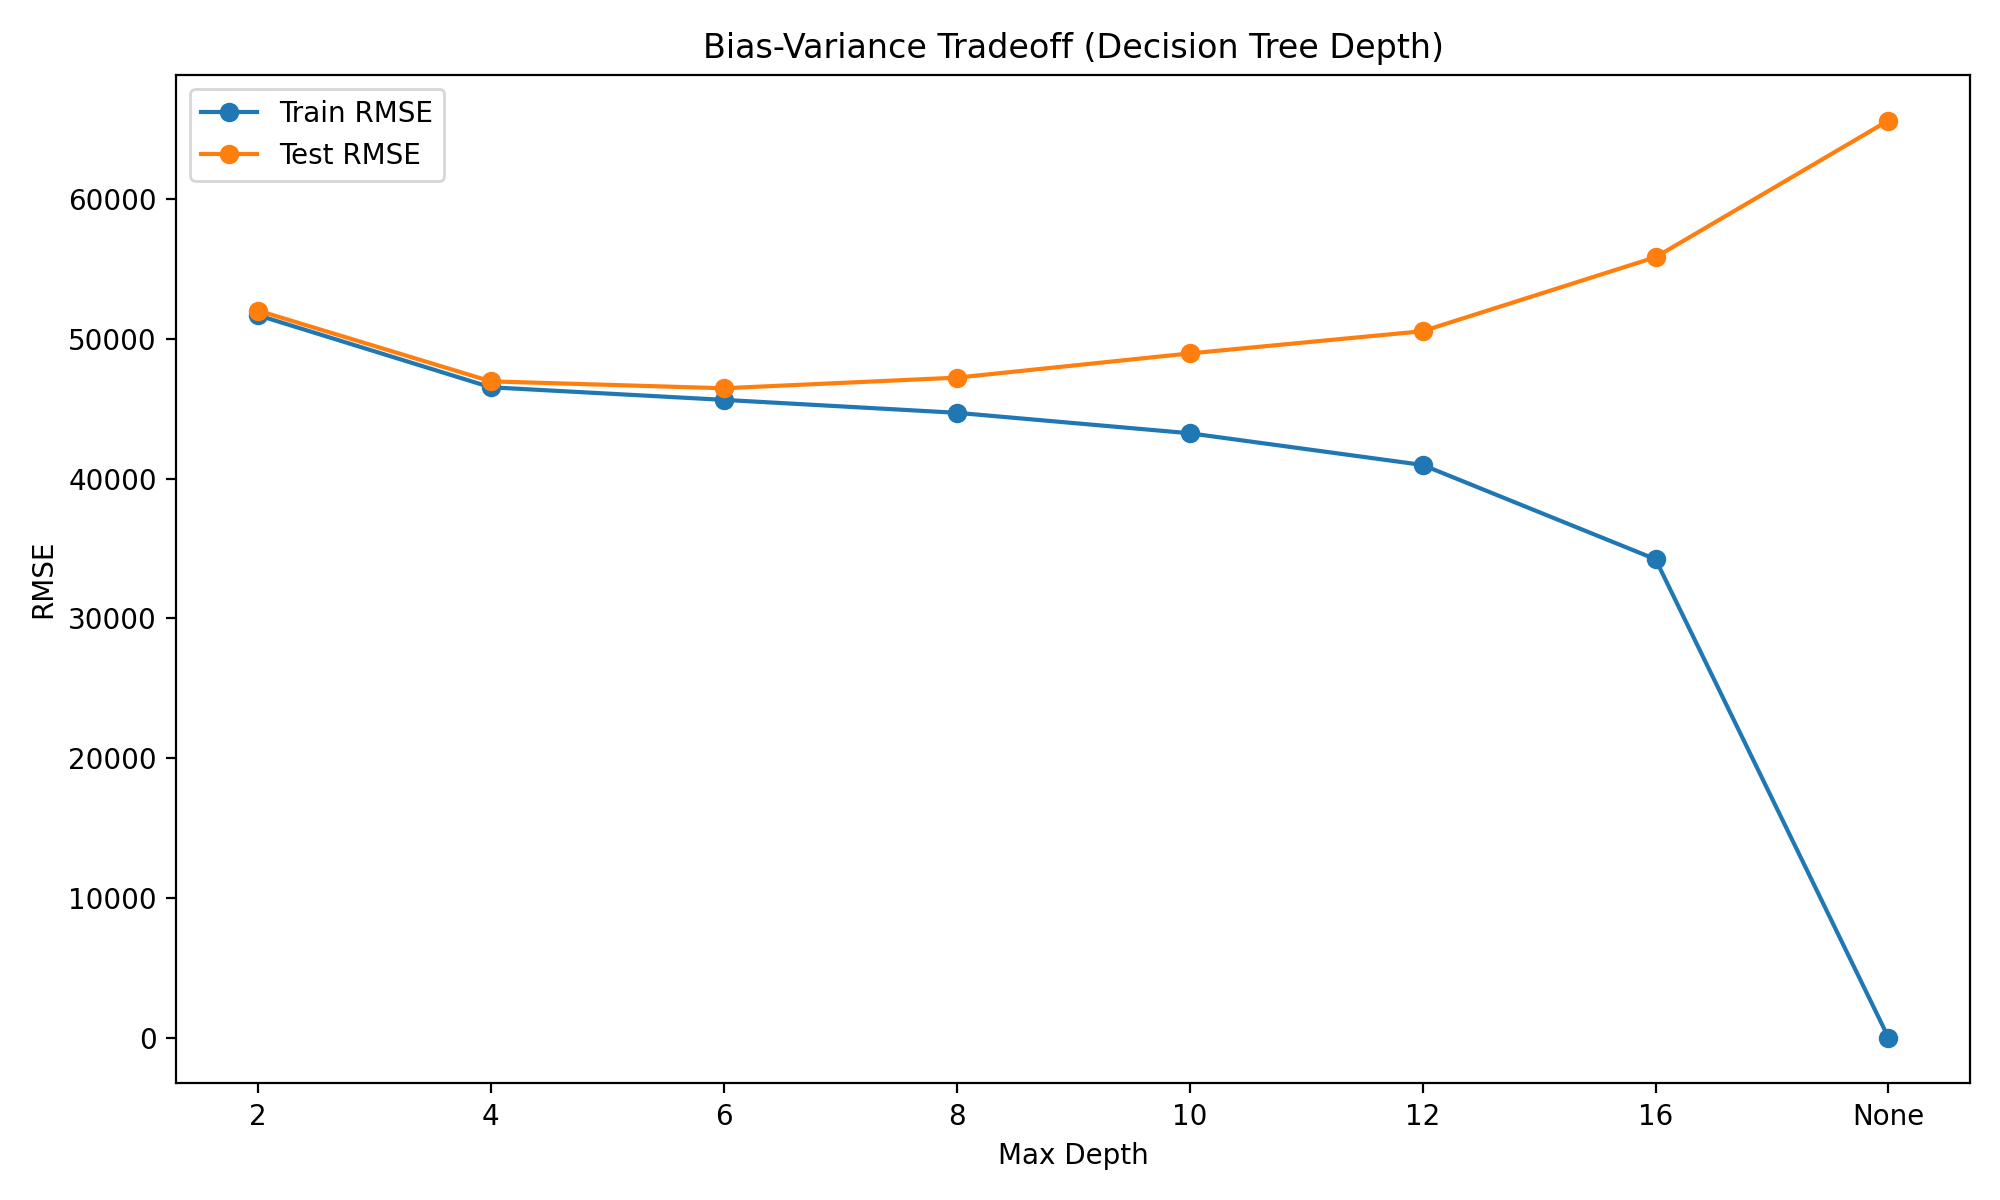

model_test_rmse_comparison.png


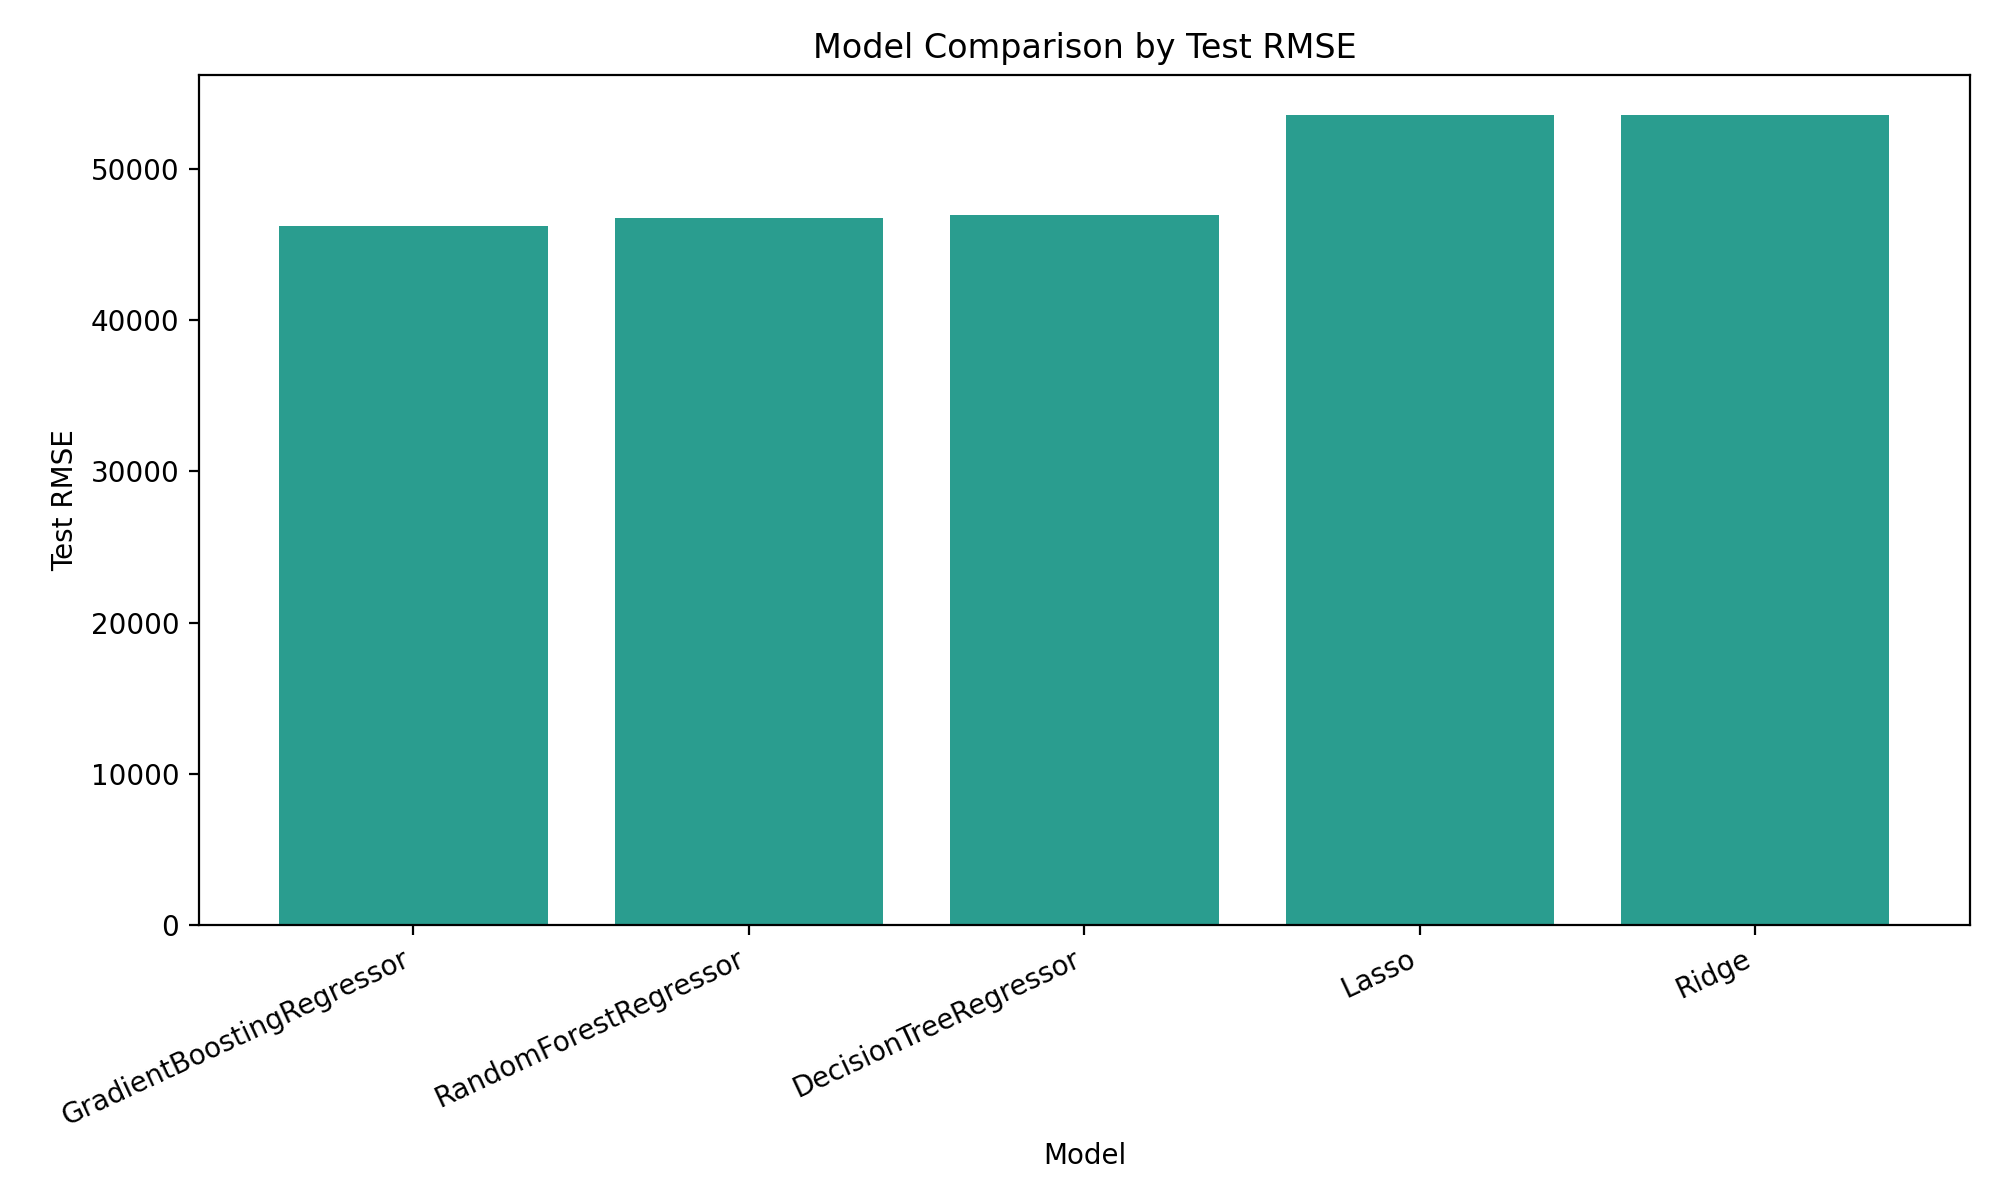

regularization_effect.png


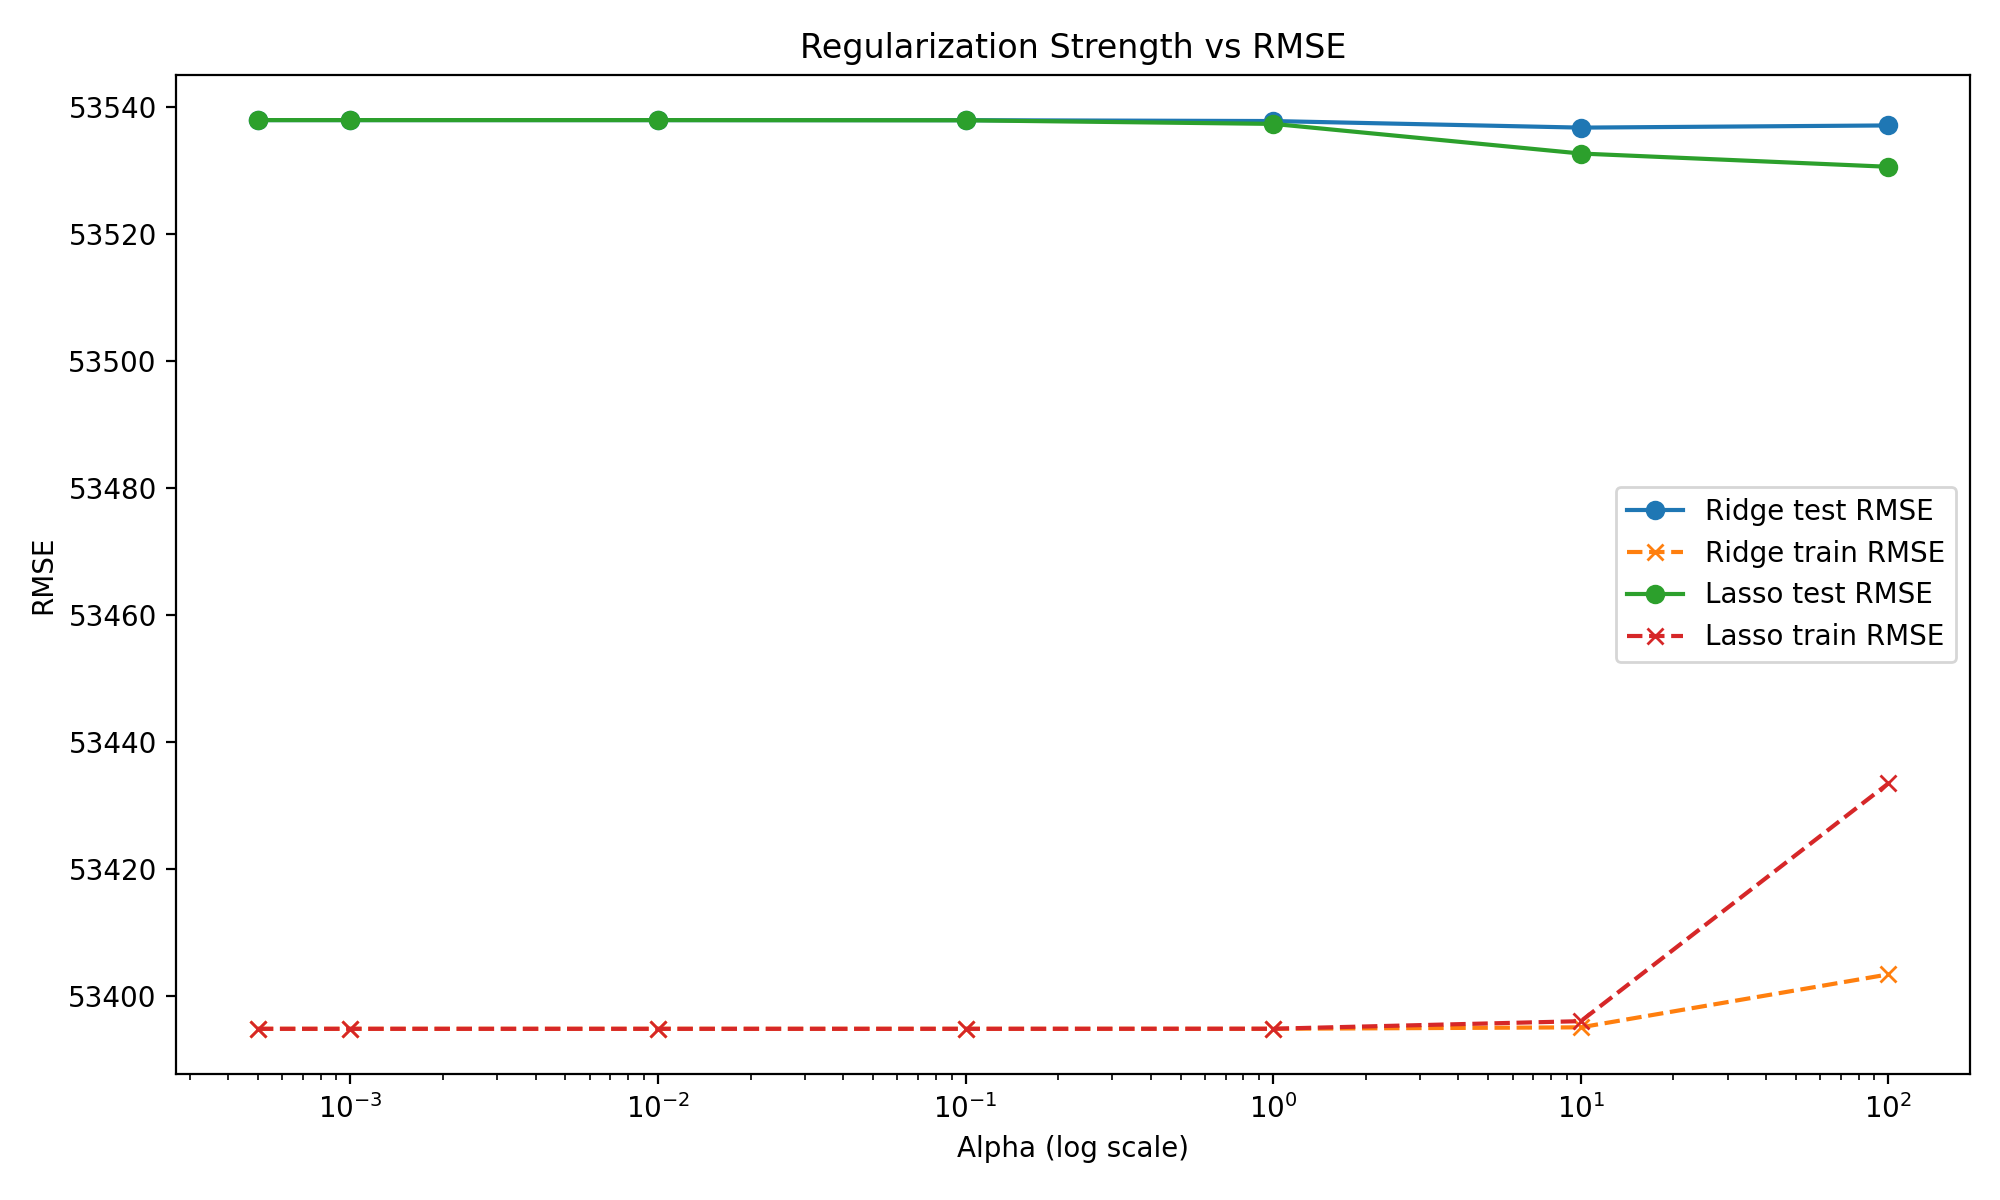

In [18]:
# Stage 4 and Stage 5 review using script outputs (no duplicated plotting logic in notebook).

# Stage 4 ---------------------------------------------------------------------
stage4_settings = Stage4Settings.from_env()
stage4_outputs = run_stage_4(settings=stage4_settings)

print('Stage 4 summary:', stage4_outputs.summary_path)
print('Stage 4 metrics:', stage4_outputs.metrics_path)

stage4_metrics = json.loads(Path(stage4_outputs.metrics_path).read_text(encoding='utf-8'))
print('Stage 4 test metrics:')
display(pd.DataFrame([stage4_metrics.get('test_metrics', {})]).rename(index={0: 'baseline_linear_regression'}))

print('Stage 4 diagnostic plots (from stage4_baseline.py):')
for plot_path in sorted(stage4_outputs.plots_directory.glob('*.png')):
    print(plot_path.name)
    display(Image(filename=str(plot_path)))


# Stage 5 ---------------------------------------------------------------------
stage5_settings = Stage5Settings.from_env()
stage5_outputs = run_stage_5(settings=stage5_settings)

print('Stage 5 summary:', stage5_outputs.summary_report_path)
print('Stage 5 comparison table:', stage5_outputs.comparison_table_path)
print('Stage 5 best model:', stage5_outputs.best_model_path)

comparison_df = pd.read_csv(stage5_outputs.comparison_table_path)
print('Stage 5 model comparison (sorted by test RMSE):')
display(comparison_df.sort_values('test_rmse').reset_index(drop=True))

feature_impact_df = pd.read_csv(stage5_outputs.best_model_importance_path)
if {'feature_name', 'importance'}.issubset(feature_impact_df.columns) and not feature_impact_df.empty:
    print('Top 10 feature impacts from Stage 5 best model:')
    display(feature_impact_df.head(10))

print('Stage 5 diagnostic plots (from stage5_advanced.py):')
for plot_path in sorted(stage5_outputs.plots_directory.glob('*.png')):
    print(plot_path.name)
    display(Image(filename=str(plot_path)))
